In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

caminho = '../data/dataset.csv'

if os.path.exists(caminho):
    df = pd.read_csv(caminho)
    print(f"✅ Dataset carregado com sucesso! Total de textos: {len(df)}")
else:
    print("⚠️ ERRO: O dataset.csv não foi encontrado.")
    df = pd.DataFrame() # Cria um dataframe vazio para não dar erro no resto do código
    
df.head()

✅ Dataset carregado com sucesso! Total de textos: 10995


,text,label
0,Trauma and Crisis Intervention Essay Trauma is...,human
1,This paper explores the emergence of popularit...,openai
2,Microbiology: Influenza Viruses Research Paper...,human
3,"In this paper, we propose a novel inference me...",human
4,Aspects of an Ethical Flaw in Business Essay T...,human


Distribuição das classes:
label
human     9556
openai    1439
Name: count, dtype: int64


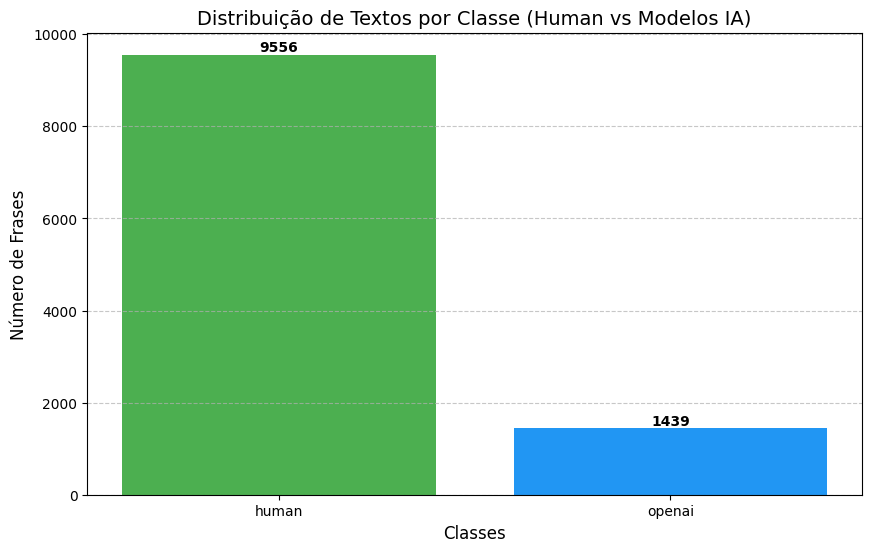

In [25]:
# Contar quantos textos temos de cada classe
contagem_classes = df['label'].value_counts()
print("Distribuição das classes:")
print(contagem_classes)

# Criar um gráfico de barras bonito
plt.figure(figsize=(10, 6))
bars = plt.bar(contagem_classes.index, contagem_classes.values, color=['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#F44336'])

# Adicionar o número exato em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Distribuição de Textos por Classe (Human vs Modelos IA)', fontsize=14)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Número de Frases', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

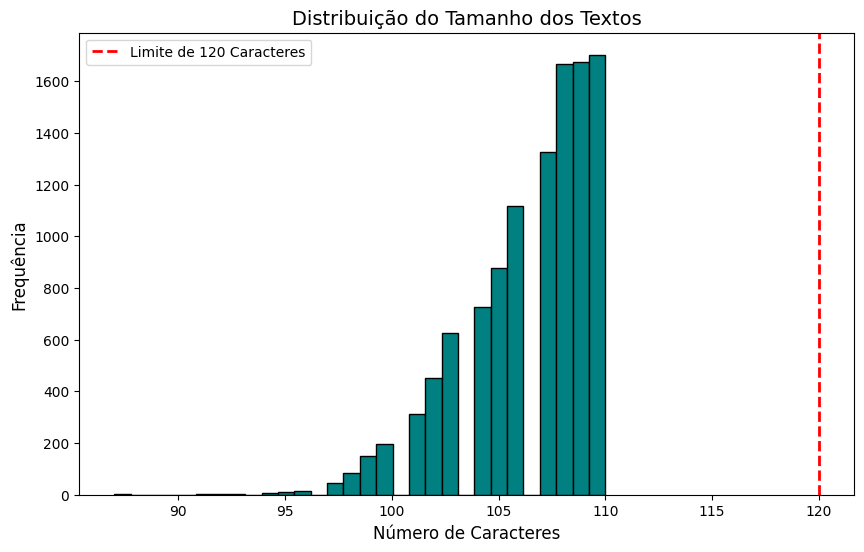

Tamanho médio dos textos: 106.5 caracteres
Tamanho máximo: 110 caracteres
Tamanho mínimo: 87 caracteres


In [26]:
# Calcular o tamanho de cada texto
df['tamanho_texto'] = df['text'].apply(lambda x: len(str(x)))

# Fazer um Histograma para mostrar a distribuição dos tamanhos
plt.figure(figsize=(10, 6))
plt.hist(df['tamanho_texto'], bins=30, color='teal', edgecolor='black')

# Adicionar uma linha vermelha a marcar a nossa meta (ex: 120 caracteres)
plt.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Limite de 120 Caracteres')

plt.title('Distribuição do Tamanho dos Textos', fontsize=14)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.show()

print(f"Tamanho médio dos textos: {df['tamanho_texto'].mean():.1f} caracteres")
print(f"Tamanho máximo: {df['tamanho_texto'].max()} caracteres")
print(f"Tamanho mínimo: {df['tamanho_texto'].min()} caracteres")

In [27]:
# Guardar em CSV na pasta data
caminho_csv = '../data/dataset.csv'

# Baralhar os dados antes de guardar
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

df_final.to_csv(caminho_csv, index=False)

print(f"✅ Dataset guardado com sucesso em: {caminho_csv}")

✅ Dataset guardado com sucesso em: ../data/dataset.csv
